In [1]:
!pip install langgraph langchain

In [2]:
from typing import TypedDict
from langgraph.graph import StateGraph

In [3]:
# create our state schema
class AgentState(TypedDict):
  name: str
  age: int
  greeting:str


In [8]:
# Our first node--->A function that perfoms a task
def my_name(state:AgentState)-> AgentState:
  """Node responsible for updating our name"""
  state['name']="Allan"

  return state

# Second node
def my_age(state:AgentState)-> AgentState:
  """Node updates our age"""
  state['age']=22
  return state

# Third node
def greeting(state: AgentState)-> AgentState:
  """Offere greeting to the user"""
  state['age']=str(state['age'])
  state['greeting']= "Hey " + state['name'] + ". You are " + state['age'] + " old."

  return state

In [9]:
# create our graph
graph=StateGraph(AgentState)

# add our nodes
graph.add_node("name", my_name)
graph.add_node("age", my_age)
graph.add_node("greeting", greeting)

# Edge: Connects the nodes together. We get the workflow
# set entry first. Begining
graph.set_entry_point("name")
graph.add_edge("name", "age")
graph.add_edge("age", "greeting")
# set exit. ENd of workflow
graph.set_finish_point("greeting")

# Compile our Graph---> Turns workflow to an executable
app=graph.compile()


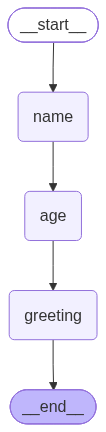

In [10]:
#Now lets visualize the flow of our graph
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [11]:
# Invoke the graph---> Runs the graph with an initial state
app.invoke({})

{'name': 'Allan', 'age': '22', 'greeting': 'Hey Allan. You are 22 old.'}